In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
sns.set_palette('deep')

In [3]:
nhts_data = pd.read_csv('NHTS(in).csv')
ngsim_data = pd.read_csv('NGSIM(in).csv')

#nhts_data.head()
ngsim_data.tail()

#nhts_data.describe()

,Time,leader_position(m),follower_position(m),leader_speed(m/s),follower_speed(m/s),leader_acc(m/s^2),follower_acc(m/s^2),trajectory_number
8161,52.8,458.63,443.59,8.5923,8.3485,3.81000,3.35280,16
8162,52.9,459.49,444.43,8.9733,8.6838,1.82880,4.32820,16
8163,53.0,460.38,445.29,9.1562,9.1166,0.45720,1.24970,16
8164,53.1,461.30,446.21,9.2019,9.2415,-0.57912,-0.82296,16
8165,53.2,462.22,447.13,9.1440,9.1592,0.00000,-0.21336,16


In [3]:
#The code below will plot a Bar chart displaying the household size by the 

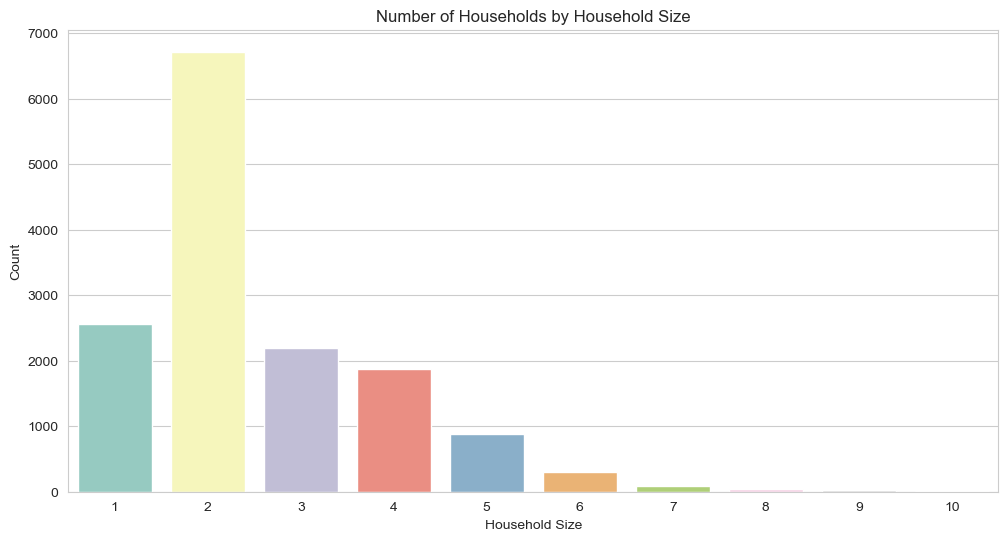

In [4]:

plt.figure(figsize=(12,6))
sns.countplot(data=nhts_data, x='household_size',hue='household_size', palette='Set3', legend = False)

plt.title('Number of Households by Household Size')
plt.xlabel('Household Size')
plt.ylabel('Count')
plt.show()



In [5]:
#Hisrogram Vehicle type count

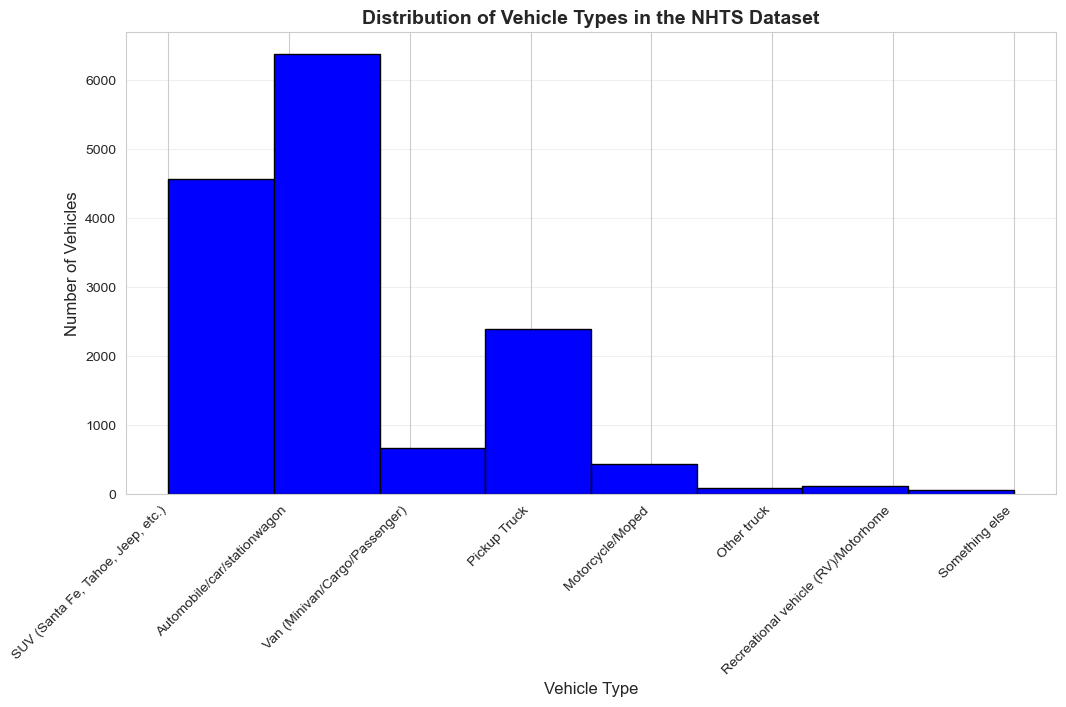

In [6]:

plt.figure(figsize=(12,6))

plt.hist(
    nhts_data['vehicle_type'].dropna(),
    bins=len(nhts_data['vehicle_type'].unique()),
    edgecolor='black',
    color='blue'
)

plt.title('Distribution of Vehicle Types in the NHTS Dataset', fontsize=14, fontweight='bold')
plt.xlabel('Vehicle Type', fontsize=12)
plt.ylabel('Number of Vehicles', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)

plt.show()


In [7]:
#Boxplot, vehicles age by vehicle type

C:\Users\anice\AppData\Local\Temp\ipykernel_63160\338046962.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


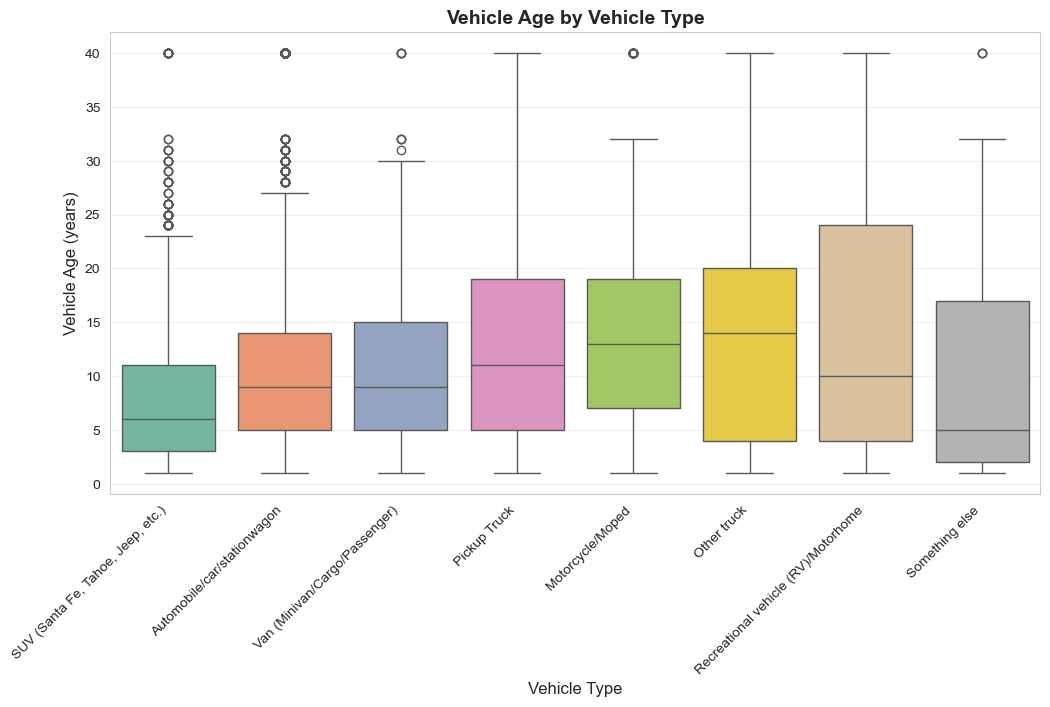

In [8]:

plt.figure(figsize=(12,6))

sns.boxplot(
    data=nhts_data,
    x='vehicle_type',
    y='vehicle_age',
    palette='Set2',
    legend = True
)

plt.title('Vehicle Age by Vehicle Type', fontsize=14, fontweight='bold')
plt.xlabel('Vehicle Type', fontsize=12)
plt.ylabel('Vehicle Age (years)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)

plt.show()


In [9]:
# Leader vs Follower position over time

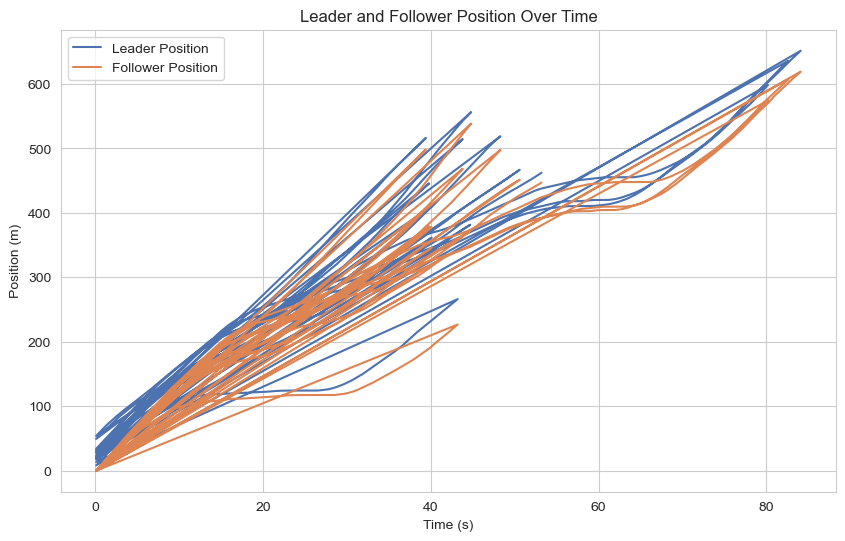

In [10]:
plt.figure(figsize=(10,6))
#sns.lineplot(x = ngsim_data['Time'], y = ngsim_data['leader_position(m)'], label='Leader Position')
plt.plot(ngsim_data['Time'], ngsim_data['leader_position(m)'], label='Leader Position')
#sns.lineplot(x = ngsim_data['Time'], y = ngsim_data['follower_position(m)'], label='Follower Position')
plt.plot(ngsim_data['Time'], ngsim_data['follower_position(m)'],  label='Follower Position')

plt.title('Leader and Follower Position Over Time')
plt.xlabel('Time (s)')
plt.ylabel('Position (m)')
plt.legend()
plt.grid(alpha=1)
plt.show()


In [11]:
#Leader vs follower Speed over time

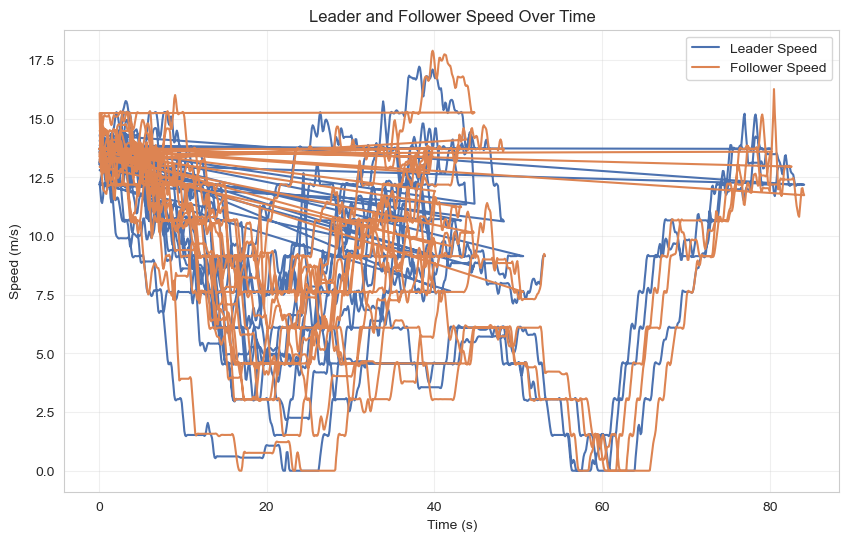

In [12]:
plt.figure(figsize=(10,6))
plt.plot(ngsim_data['Time'], ngsim_data['leader_speed(m/s)'], label='Leader Speed')
plt.plot(ngsim_data['Time'], ngsim_data['follower_speed(m/s)'], label='Follower Speed')

plt.title('Leader and Follower Speed Over Time')
plt.xlabel('Time (s)')
plt.ylabel('Speed (m/s)')
plt.legend()
plt.grid(alpha=0.3)
plt.show()


In [13]:
# IDM Similation for the speed

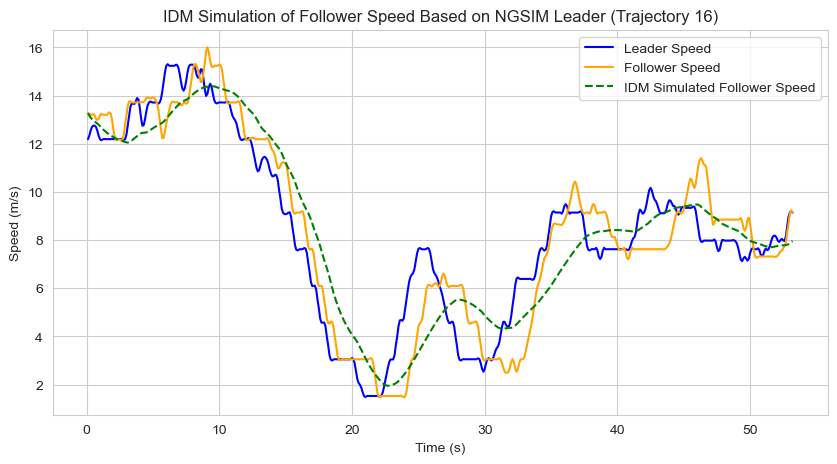

In [14]:

df = ngsim_data[ngsim_data["trajectory_number"] == 16].copy()

# Sort by time just to be safe
df = df.sort_values("Time")

time = df["Time"].values
dt = np.mean(np.diff(time))   # should be 0.1 seconds

x_lead = df["leader_position(m)"].values
v_lead = df["leader_speed(m/s)"].values

# Initial follower state from NGSIM
x_foll_sim = np.zeros_like(x_lead)
v_foll_sim = np.zeros_like(v_lead)

x_foll_sim[0] = df["follower_position(m)"].values[0]
v_foll_sim[0] = df["follower_speed(m/s)"].values[0]

# 2. IDM Parameters

v0 = 30.0        # desired speed (m/s)
T = 1.5          # desired time headway (s)
a_max = 1      # max acceleration (m/s^2)
b = 2.0          # comfortable deceleration (m/s^2)
s0 = 2.0         # minimum gap (m)
delta = 4        # acceleration exponent


# 3. IDM Simulation Loop

for i in range(len(time)-1):

    # Gap between leader and simulated follower
    s = x_lead[i] - x_foll_sim[i]

    # Relative speed (positive = follower faster)
    dv = v_foll_sim[i] - v_lead[i]

    # Desired dynamic gap
    s_star = s0 + v_foll_sim[i]*T + (v_foll_sim[i] * dv) / (2 * np.sqrt(a_max * b))

    # IDM acceleration
    acc = a_max * (1 - (v_foll_sim[i]/v0)**delta - (s_star/s)**2)

    # Euler integration
    v_foll_sim[i+1] = v_foll_sim[i] + acc * dt
    v_foll_sim[i+1] = max(v_foll_sim[i+1], 0)  # no negative speeds

    x_foll_sim[i+1] = x_foll_sim[i] + v_foll_sim[i] * dt

# 4. Plot Speed Comparison

plt.figure(figsize=(10,5))
plt.plot(time, v_lead, label="Leader Speed", color="blue")
plt.plot(time, df["follower_speed(m/s)"], label="Follower Speed", color="orange")
plt.plot(time, v_foll_sim, label="IDM Simulated Follower Speed", color="green", linestyle="--")

plt.xlabel("Time (s)")
plt.ylabel("Speed (m/s)")
plt.title("IDM Simulation of Follower Speed Based on NGSIM Leader (Trajectory 16)")
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
#IDM Visualization of follower acceleration

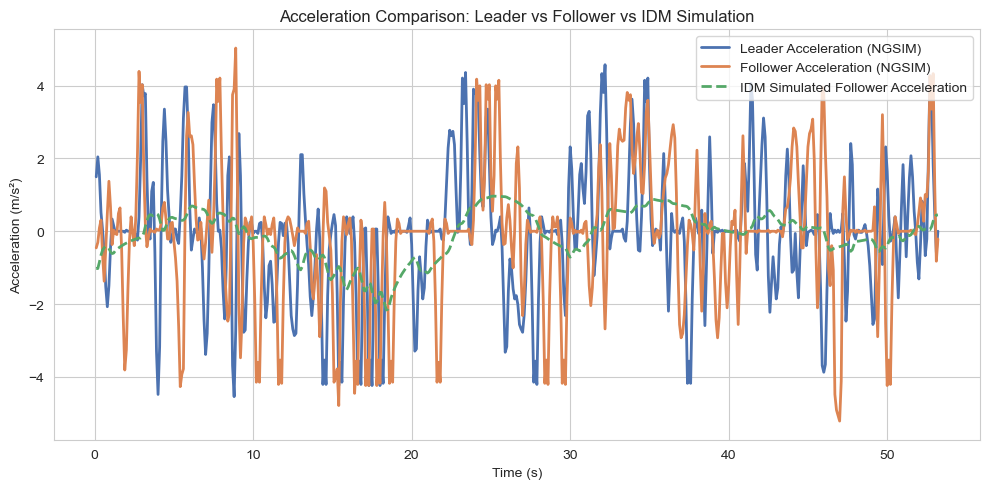

In [15]:

# Leader and follower accelerations from NGSIM
acc_lead = df["leader_acc(m/s^2)"].values
acc_foll = df["follower_acc(m/s^2)"].values

# IDM-simulated follower acceleration (finite difference)
acc_foll_sim = np.zeros_like(v_foll_sim)
acc_foll_sim[1:] = np.diff(v_foll_sim) / dt
acc_foll_sim[0] = acc_foll_sim[1]   # smooth the first point


plt.figure(figsize=(10,5))
plt.plot(time, acc_lead, label="Leader Acceleration (NGSIM)", linewidth=2)
plt.plot(time, acc_foll, label="Follower Acceleration (NGSIM)", linewidth=2)
plt.plot(time, acc_foll_sim, label="IDM Simulated Follower Acceleration", linestyle="--", linewidth=2)

plt.xlabel("Time (s)")
plt.ylabel("Acceleration (m/s²)")
plt.title("Acceleration Comparison: Leader vs Follower vs IDM Simulation")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
